Import Libraries

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score, GridSearchCV, KFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.svm import SVC

Load Data

In [2]:
# Load data
df = pd.read_csv("nyc_traffic_ml_orig.csv")

In [3]:
df.shape

(28904, 29)

In [5]:
df.head()

,Segment_ID,Is_Weekend,Daylight,Season1,Season2,Season4,Hr3,Hr6,Hr9,Hr12,...,BoroCode1,BoroCode2,BoroCode3,BoroCode4,BoroCode5,LandUse_t1,LandUse_t2,LandUse_t3,LandUse_t4,LandUse_t5
0,132595,0,0.012580,0,0,1,1,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.764192,0.122271,0.026201,0.052402,0.034934
1,132595,0,0.190699,0,0,1,0,1,0,0,...,0.0,1.0,0.0,0.0,0.0,0.764192,0.122271,0.026201,0.052402,0.034934
2,132595,0,0.725938,0,0,1,0,0,1,0,...,0.0,1.0,0.0,0.0,0.0,0.764192,0.122271,0.026201,0.052402,0.034934
3,132595,0,1.000000,0,0,1,0,0,0,1,...,0.0,1.0,0.0,0.0,0.0,0.764192,0.122271,0.026201,0.052402,0.034934
4,132595,0,0.725938,0,0,1,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.764192,0.122271,0.026201,0.052402,0.034934


Categorical target

In [78]:
# Categorize target
max_value = df['Traffic_Volume'].max()
split_1, split_2 = max_value / 3, max_value * 2 / 3
df['Traffic_Level'] = pd.cut(df['Traffic_Volume'], bins=[0, split_1, split_2, np.inf], labels=[0, 1, 2])

# Drop NaN
df = df.dropna(subset=['Traffic_Level'])

# Drop Segment_ID and Traffic_Volume
df.drop(columns=['Segment_ID', 'Traffic_Volume'], inplace=True)

X = df.drop(columns=['Traffic_Level'])
y = df['Traffic_Level'].astype(int)

X.shape, y.shape

<ipython-input-78-f2149f70bc97>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['Segment_ID', 'Traffic_Volume'], inplace=True)


((28903, 27), (28903,))

Handle class-imbalance

Class=0, n=27365 (94.679%)
Class=1, n=1461 (5.055%)
Class=2, n=77 (0.266%)


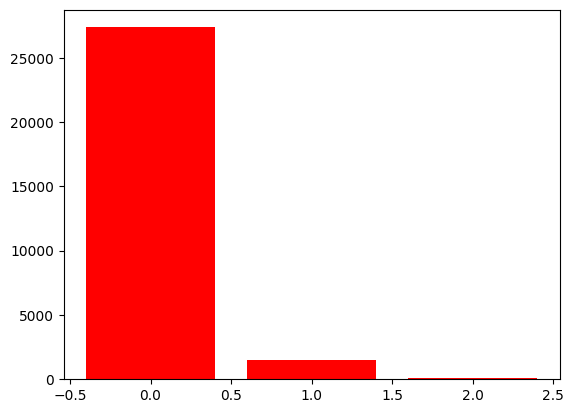

In [79]:
# Summarize Traffic Level Distribution
levels = df['Traffic_Level'].values
counter = Counter(levels)
for i,j in counter.items():
    per = j / len(levels) * 100
    print('Class=%d, n=%d (%.3f%%)' % (i, j, per))
plt.bar(counter.keys(), counter.values(), color='red')
plt.show()

Train-test Split

In [80]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Apply SMOTE to training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

Class=0, n=19155 (33.333%)
Class=1, n=19155 (33.333%)
Class=2, n=19155 (33.333%)


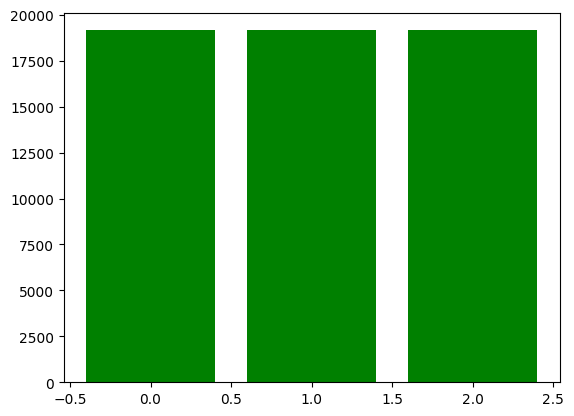

In [81]:
# Summarize Traffic Level Distribution after SMOTE
levels = y_train_res.values
counter = Counter(levels)
for i,j in counter.items():
    per = j / len(levels) * 100
    print('Class=%d, n=%d (%.3f%%)' % (i, j, per))
plt.bar(counter.keys(), counter.values(), color='green')
plt.show()

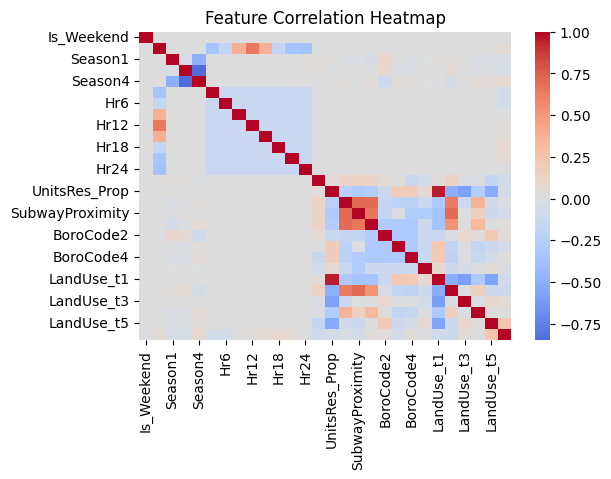

In [66]:
plt.figure(figsize=(6, 4))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

PCA Analysis

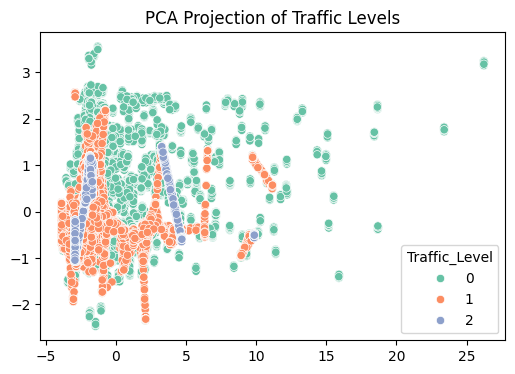

In [53]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_res)

plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train_res, palette='Set2')
plt.title("PCA Projection of Traffic Levels")
plt.show()

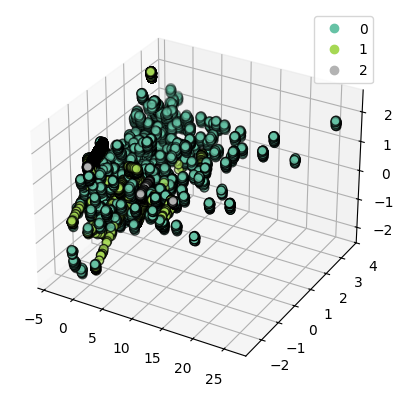

In [45]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_train_res)

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
    c=y_train_res, cmap='Set2', edgecolor='k', s=40
)

legend_labels = list(set(y_train_res))
ax.legend(handles=scatter.legend_elements()[0], labels=legend_labels)
plt.tight_layout()
plt.show()

Non linear SVM prediction

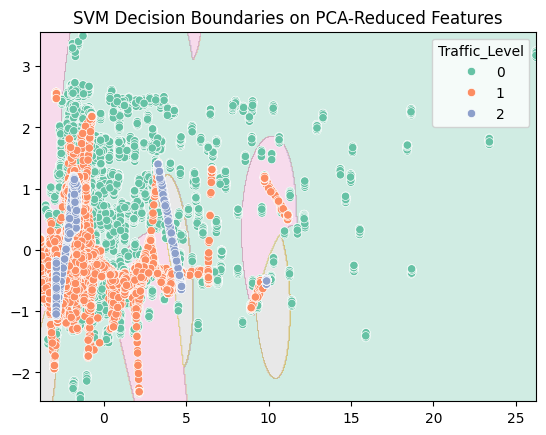

In [37]:
X_pca = PCA(n_components=2).fit_transform(X_train_res)
svm_rbf_2d = SVC(kernel='rbf', C=1, gamma='scale')
svm_rbf_2d.fit(X_pca, y_train_res)

xx, yy = np.meshgrid(np.linspace(X_pca[:, 0].min(), X_pca[:, 0].max(), 500),
                     np.linspace(X_pca[:, 1].min(), X_pca[:, 1].max(), 500))
Z = svm_rbf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set2')
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train_res, palette='Set2')
plt.title("SVM Decision Boundaries on PCA-Reduced Features")
plt.show()

Random Forest

In [93]:
# Fit initial Random Forest
clf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
clf.fit(X_train_res, y_train_res)

# Evaluation on test set
y_pred = clf.predict(X_test)
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred))
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      8210
           1       0.82      0.88      0.85       438
           2       0.72      0.78      0.75        23

    accuracy                           0.98      8671
   macro avg       0.85      0.89      0.86      8671
weighted avg       0.98      0.98      0.98      8671

Random Forest Confusion Matrix:
 [[8129   78    3]
 [  47  387    4]
 [   0    5   18]]


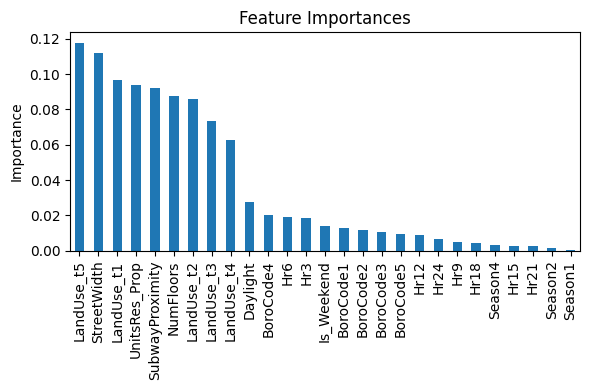

In [94]:
# Feature importance plot
feat_imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(6, 4))
feat_imp.plot(kind='bar', title='Feature Importances')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [89]:
X_train_res_new = X_train_res.drop(columns = ['Season1', 'Season2'])
X_test_new = X_test.drop(columns = ['Season1', 'Season2'])
X_train_res_new.shape, X_test_new.shape

((57465, 25), (8671, 25))

In [90]:
df.columns

Index(['Is_Weekend', 'Daylight', 'Season1', 'Season2', 'Season4', 'Hr3', 'Hr6',
       'Hr9', 'Hr12', 'Hr15', 'Hr18', 'Hr21', 'Hr24', 'StreetWidth',
       'UnitsRes_Prop', 'NumFloors', 'SubwayProximity', 'BoroCode1',
       'BoroCode2', 'BoroCode3', 'BoroCode4', 'BoroCode5', 'LandUse_t1',
       'LandUse_t2', 'LandUse_t3', 'LandUse_t4', 'LandUse_t5',
       'Traffic_Level'],
      dtype='object')

In [91]:
# Fit initial Random Forest
clf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
clf.fit(X_train_res_new, y_train_res)

# Evaluation on test set
y_pred = clf.predict(X_test_new)
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred))
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      8210
           1       0.82      0.88      0.85       438
           2       0.75      0.78      0.77        23

    accuracy                           0.98      8671
   macro avg       0.85      0.88      0.87      8671
weighted avg       0.98      0.98      0.98      8671

Random Forest Confusion Matrix:
 [[8127   80    3]
 [  50  385    3]
 [   0    5   18]]


K-Fold cross-validation

In [92]:
# Evaluating model on cross-validation folds
def evaluate_model(X, y, model):
    cv = KFold(n_splits=5, shuffle=True, random_state=1)
    scores = []

    # Split the data into folds and evaluate on each fold
    for train_index, val_index in cv.split(X):
        X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
        y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

        # Train the model on the current fold
        model.fit(X_train_fold, y_train_fold)

        # Predict on the validation fold
        y_pred_fold = model.predict(X_val_fold)

        # Evaluate accuracy for this fold
        fold_accuracy = accuracy_score(y_val_fold, y_pred_fold)
        scores.append(fold_accuracy)

    return scores

scores = evaluate_model(X_train, y_train, clf)
print(f"Cross-validation accuracy: {np.mean(scores)}")

# After cross-validation, fit the model on the entire training data and test on the test set
clf.fit(X_train_res, y_train_res)
y_test_pred = clf.predict(X_test)

# Test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test set accuracy: {test_accuracy}")

Cross-validation accuracy: 0.98195922331781
Test set accuracy: 0.9842002075885135


Boosting Models

In [101]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Initialize models
xgb = XGBClassifier(n_estimators=500, random_state=42, n_jobs=-1)
lgbm = LGBMClassifier(n_estimators=500, random_state=42, n_jobs=-1)
catboost = CatBoostClassifier(iterations=500, random_state=42, verbose=0)

# Train
xgb.fit(X_train_res, y_train_res)
lgbm.fit(X_train_res, y_train_res)
catboost.fit(X_train_res, y_train_res)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006570 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3611
[LightGBM] [Info] Number of data points in the train set: 57465, number of used features: 27
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


In [102]:
xgb_y_pred = xgb.predict(X_test)
lgbm_y_pred = lgbm.predict(X_test)
catboost_y_pred = catboost.predict(X_test)

print("XGB Classification Report:\n", classification_report(y_test, xgb_y_pred))
print("XGB Confusion Matrix:\n", confusion_matrix(y_test, xgb_y_pred))

print("LGBM Classification Report:\n", classification_report(y_test, lgbm_y_pred))
print("LGBM Confusion Matrix:\n", confusion_matrix(y_test, lgbm_y_pred))

print("CatBoost Classification Report:\n", classification_report(y_test, catboost_y_pred))
print("CatBoost Confusion Matrix:\n", confusion_matrix(y_test, catboost_y_pred))

XGB Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      8210
           1       0.86      0.90      0.88       438
           2       0.89      0.74      0.81        23

    accuracy                           0.99      8671
   macro avg       0.92      0.88      0.89      8671
weighted avg       0.99      0.99      0.99      8671

XGB Confusion Matrix:
 [[8152   57    1]
 [  44  393    1]
 [   0    6   17]]
LGBM Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      8210
           1       0.89      0.89      0.89       438
           2       0.94      0.74      0.83        23

    accuracy                           0.99      8671
   macro avg       0.94      0.87      0.90      8671
weighted avg       0.99      0.99      0.99      8671

LGBM Confusion Matrix:
 [[8166   44    0]
 [  47  390    1]
 [   1    5   17]]
CatBoost Classification 

Ensemble

In [105]:
from sklearn.ensemble import VotingClassifier

# Create ensemble
ensemble = VotingClassifier(
    estimators=[
        ('rf', clf),
        ('xgb', xgb),
        ('lgbm', lgbm),
        ('catboost', catboost)
    ],
    voting='soft',   # soft voting uses probabilities
    n_jobs=-1
)

# Train ensemble
ensemble.fit(X_train_res, y_train_res)

# Evaluate on Test Set
y_pred_ensemble = ensemble.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred_ensemble))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ensemble))

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      8210
           1       0.86      0.89      0.88       438
           2       0.94      0.74      0.83        23

    accuracy                           0.99      8671
   macro avg       0.93      0.88      0.90      8671
weighted avg       0.99      0.99      0.99      8671

Confusion Matrix:
 [[8152   58    0]
 [  45  392    1]
 [   0    6   17]]


In [ ]:
scores = evaluate_model(X_train, y_train, ensemble)
print(f"Cross-validation accuracy: {np.mean(scores)}")

# After cross-validation, fit the model on the entire training data and test on the test set
ensemble.fit(X_train_res, y_train_res)
y_test_pred = ensemble.predict(X_test)

# Test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test set accuracy: {test_accuracy}")

/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Cross-validation accuracy: 0.9881871084456109
Test set accuracy: 0.9873140352900472


Regression using bagging and boosting models


--- Random Forest ---
R² Score: 0.9403907163630554
RMSE: 219.92793707110062
MAE: 111.07472113724344


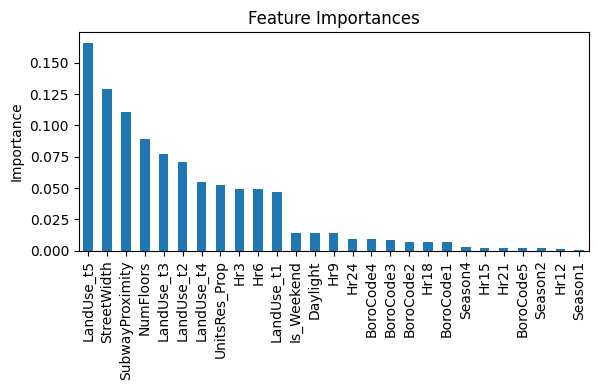

In [113]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Load data
df = pd.read_csv("nyc_traffic_ml_orig.csv")

df.drop(columns=['Segment_ID'], inplace=True)

# Label encode categorical features
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Drop NaN values from target
df.dropna(subset=['Traffic_Volume'], inplace=True)

# --- Define Features and Target ---
X = df.drop(columns=['Traffic_Volume'])
y = df['Traffic_Volume']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Random Forest Regression
rf_regr = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf_regr.fit(X_train, y_train)
y_pred_rf = rf_regr.predict(X_test)

# Feature Importance
feat_imp = pd.Series(rf_regr.feature_importances_, index=X.columns).sort_values(ascending=False)

# Evaluation Function
def evaluate_regression(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print("R² Score:", r2_score(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE:", mean_absolute_error(y_true, y_pred))

evaluate_regression(y_test, y_pred_rf, "Random Forest")

plt.figure(figsize=(6, 4))
feat_imp.plot(kind='bar', title='Feature Importances')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [114]:
# Drop less important features
df.drop(columns=['Season1', 'Season2','BoroCode5', 'Hr12'], inplace=True)

# Label encode categorical features
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Drop NaN values from target
df.dropna(subset=['Traffic_Volume'], inplace=True)

# --- Define Features and Target ---
X = df.drop(columns=['Traffic_Volume'])
y = df['Traffic_Volume']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Random Forest Regression
rf_regr = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf_regr.fit(X_train, y_train)
y_pred_rf = rf_regr.predict(X_test)

# Boosting Models
xgb_regr = XGBRegressor(n_estimators=500, random_state=42, n_jobs=-1)
lgbm_regr = LGBMRegressor(n_estimators=500, random_state=42, n_jobs=-1)
catboost_regr = CatBoostRegressor(iterations=500, random_state=42, verbose=0)

# Train boosting models
xgb_regr.fit(X_train, y_train)
lgbm_regr.fit(X_train, y_train)
catboost_regr.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_regr.predict(X_test)
y_pred_lgbm = lgbm_regr.predict(X_test)
y_pred_cat = catboost_regr.predict(X_test)

# Evaluate Models
evaluate_regression(y_test, y_pred_rf, "Random Forest")
evaluate_regression(y_test, y_pred_xgb, "XGBoost")
evaluate_regression(y_test, y_pred_lgbm, "LightGBM")
evaluate_regression(y_test, y_pred_cat, "CatBoost")

# Ensemble CatBoost, XGBoost and Random Forest

ensemble = VotingRegressor(estimators=[
    ('cat', catboost_regr),
    ('xgb', xgb_regr),
    ('rf', rf_regr)
])

ensemble.fit(X_train, y_train)
y_pred_ensemble = ensemble.predict(X_test)

# --- Evaluate Ensemble ---
evaluate_regression(y_test, y_pred_ensemble, "Voting Ensemble (CatBoost + XGBoost + RF)")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001814 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2331
[LightGBM] [Info] Number of data points in the train set: 20232, number of used features: 23
[LightGBM] [Info] Start training from score 764.014828

--- Random Forest ---
R² Score: 0.9403612979766631
RMSE: 219.98219981822442
MAE: 111.09127181544501

--- XGBoost ---
R² Score: 0.9498318630672938
RMSE: 201.7610994412844
MAE: 117.7019290284182

--- LightGBM ---
R² Score: 0.9426364158760456
RMSE: 215.74542176118106
MAE: 136.98111161411882

--- CatBoost ---
R² Score: 0.8993222214366712
RMSE: 285.8184511136886
MAE: 193.30972235487476

--- Voting Ensemble (CatBoost + XGBoost + RF) ---
R² Score: 0.9541375510790443
RMSE: 192.90881344582962
MAE: 115.47131581286516
